# Phase 3: Structure from Motion (SfM)

**Pipeline position:**
```
Phase 1: Synthetic Scene       ✓
Phase 2: Feature Matching      ✓
Phase 3: Structure from Motion ← YOU ARE HERE
Phase 4: Dense Depth (MVS)
...
```

---

## What is Structure from Motion?

SfM solves a chicken-and-egg problem:
- To know where the cameras are, you need to know the 3-D scene structure.
- To know the 3-D structure, you need to know where the cameras are.

SfM breaks this deadlock by recovering **both simultaneously** from 2-D correspondences alone.  The output is:
1. **Camera poses** — the $[R|t]$ for every image
2. **Sparse 3-D point cloud** — one 3-D point per matched feature group

"Sparse" means only hundreds to thousands of points (at feature locations), not millions.  The dense reconstruction comes later in Phase 4.

---

## The Scale Ambiguity Problem

This is one of the most important concepts in SfM:

> **Monocular SfM can only recover structure up to an unknown global scale.**

If you double all camera translations AND all 3-D point coordinates, every image projection stays exactly the same — you cannot distinguish "small scene, close cameras" from "large scene, far cameras" from images alone.

**Convention:** fix $|\mathbf{t}| = 1$ for the first camera pair.  The resulting reconstruction is in **SfM scale**, not metric scale.  In real deployments, scale is resolved by:
- GPS-tagged camera positions
- Known ground control points
- IMU integration

In our synthetic setup we have **metric ground truth**, so we can directly evaluate pose accuracy in degrees and metres.

---

## The 4-Step Incremental SfM Pipeline

```
1. Two-view initialization
   Select best initial pair → Essential matrix → recover R, t → triangulate sparse cloud

2. Incremental camera registration
   For each new camera: find 3D-2D correspondences → PnP → add pose

3. Triangulate new points
   New camera pairs → DLT triangulation → grow the cloud

4. Bundle Adjustment
   Jointly optimise ALL poses and 3-D points → minimise total reprojection error
```

Steps 2-3 repeat until all cameras are registered; then step 4 refines everything.

In [1]:
import sys, os
sys.path.insert(0, os.path.join(os.getcwd(), '..'))

import numpy as np
import cv2
import open3d as o3d
import matplotlib.pyplot as plt
import json
%matplotlib inline

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


In [2]:
img_dir    = os.path.join('..', 'data', 'synthetic', 'images')
poses_path = os.path.join('..', 'data', 'synthetic', 'GT_poses.json')
assert os.path.isdir(img_dir), "Run phase1_data_generation.ipynb first."

img_files = sorted(os.listdir(img_dir))
images = [cv2.imread(os.path.join(img_dir, f)) for f in img_files]

with open(poses_path) as f:
    gt_poses = json.load(f)

K = np.array(gt_poses[0]['K'])
print(f"Loaded {len(images)} images")
print(f"Intrinsic K (ground truth, shared by all cameras):\n{K.astype(int)}")

Loaded 16 images
Intrinsic K (ground truth, shared by all cameras):
[[692   0 400]
 [  0 692 300]
 [  0   0   1]]


In [3]:
# Re-run feature detection and matching (same as Phase 2).
# In a production pipeline these would be loaded from disk.
from src.features.detector import detect_features
from src.features.matcher import match_features

print("Detecting features...")
features = detect_features(images, nfeatures=2048)
print("Matching features...")
match_graph = match_features(features, ratio=0.75, min_inliers=20)
print(f"Match graph: {len(match_graph)} verified pairs")

Detecting features...
  [detector] img 0000: 98 keypoints
  [detector] img 0001: 108 keypoints
  [detector] img 0002: 199 keypoints
  [detector] img 0003: 103 keypoints
  [detector] img 0004: 102 keypoints
  [detector] img 0005: 189 keypoints
  [detector] img 0006: 218 keypoints
  [detector] img 0007: 87 keypoints
  [detector] img 0008: 210 keypoints
  [detector] img 0009: 250 keypoints
  [detector] img 0010: 266 keypoints
  [detector] img 0011: 152 keypoints
  [detector] img 0012: 154 keypoints
  [detector] img 0013: 163 keypoints
  [detector] img 0014: 214 keypoints
  [detector] img 0015: 120 keypoints
Matching features...
  [matcher] (1,2): 30 inliers
  [matcher] (2,3): 38 inliers
  [matcher] (2,6): 30 inliers
  [matcher] (4,8): 21 inliers
  [matcher] (5,6): 37 inliers
  [matcher] (5,9): 32 inliers
  [matcher] (6,10): 32 inliers
  [matcher] (8,9): 29 inliers
  [matcher] (8,12): 53 inliers
  [matcher] (8,13): 21 inliers
  [matcher] (9,12): 22 inliers
  [matcher] (9,13): 39 inliers
  

---

## Step 1 — Two-View Initialization

### Choosing the Initial Pair

The initial pair should have:
- **Many inliers** — more correspondences = more stable geometry
- **Sufficient baseline** — cameras that are too close have near-degenerate triangulation (high depth uncertainty)

We pick the pair with the most inliers that also have a meaningful translation component.

### The Essential Matrix

For two **calibrated** cameras (K is known), the Essential matrix $E$ encodes the relative rotation and translation:

$$E = K^\top F K \qquad \text{and} \qquad E = [\mathbf{t}]_\times R$$

where $[\mathbf{t}]_\times$ is the skew-symmetric cross-product matrix of the translation vector.

$E$ has 5 degrees of freedom (3 for rotation, 2 for unit translation — scale is lost).  Given $E$, we can decompose it into 4 candidate $(R, \mathbf{t})$ pairs.  The **cheirality test** selects the unique correct one: the 3-D points must appear in front of both cameras.

`cv2.recoverPose` does all of this: it takes $E$ and the 2-D matches, performs the cheirality check using triangulation, and returns the unique $(R, \mathbf{t})$.

In [4]:
from src.sfm.two_view import recover_pose_from_match, select_initial_pair

init_pair = select_initial_pair(match_graph)
i, j = init_pair
match = match_graph[init_pair]

R_est, t_est, mask = recover_pose_from_match(match.pts_i, match.pts_j, K)

print(f"Initial pair: images ({i}, {j})  |  {len(match.pts_i)} inliers")
print(f"\nEstimated relative rotation R:")
print(R_est.round(4))
print(f"\nEstimated relative translation t (unit length by convention):")
print(t_est.round(4))
print(f"  |t| = {np.linalg.norm(t_est):.4f}  (always 1.0 — scale ambiguity)")

# Compare R with ground truth
R_gt_i = np.array(gt_poses[i]['R'])
R_gt_j = np.array(gt_poses[j]['R'])
R_rel_gt = R_gt_j @ R_gt_i.T
cos_a = np.clip((np.trace(R_est.T @ R_rel_gt) - 1) / 2, -1, 1)
angle_err = np.degrees(np.arccos(cos_a))
print(f"\nRotation error vs GT relative rotation: {angle_err:.3f}°")

Initial pair: images (14, 15)  |  55 inliers

Estimated relative rotation R:
[[ 1.     -0.0043 -0.0012]
 [ 0.0044  0.9996  0.0263]
 [ 0.0011 -0.0263  0.9997]]

Estimated relative translation t (unit length by convention):
[ 0.0036 -0.9887 -0.1499]
  |t| = 1.0000  (always 1.0 — scale ambiguity)

Rotation error vs GT relative rotation: 1.528°


---

## Step 2 — Triangulation (DLT)

With two camera matrices $P_1 = K[I|\mathbf{0}]$ and $P_2 = K[R|\mathbf{t}]$, we recover the 3-D point $\mathbf{X}$ for each correspondence $(\mathbf{x}_1, \mathbf{x}_2)$.

Each image observation gives two linear equations in the 4 homogeneous coordinates of $\mathbf{X}$:  two views → 4 equations → overdetermined system → solve by SVD.

$$A \mathbf{X} = \mathbf{0} \quad \Rightarrow \quad \mathbf{X} = \text{last column of } V \text{ (from SVD)}$$

This is the **Direct Linear Transform (DLT)**.  `cv2.triangulatePoints` implements it efficiently.

**Depth check:** after triangulation, we verify that $\mathbf{X}$ lies in front of both cameras (positive depth).  Points behind a camera indicate an incorrect $(R, \mathbf{t})$ and should be discarded.

In [6]:
from src.sfm.triangulation import triangulate_dlt, filter_cheirality, projection_matrix

# Camera 0 is placed at the origin (world reference frame)
P1 = projection_matrix(K, np.eye(3), np.zeros(3))
P2 = projection_matrix(K, R_est, t_est)

pts_i = match.pts_i[mask]
pts_j = match.pts_j[mask]

pts3d = triangulate_dlt(P1, P2, pts_i, pts_j)
valid = filter_cheirality(pts3d, P1, P2)
pts3d = pts3d[valid]

print(f"Triangulated  : {len(pts_i)} points")
print(f"After cheirality check: {len(pts3d)} valid points ({100*len(pts3d)/len(pts_i):.1f}%)")
print(f"Z range: {pts3d[:,2].min():.2f} — {pts3d[:,2].max():.2f}  (SfM scale, not metres)")
print()
print("Note: the SfM cloud is in arbitrary scale. Metric depth comes from GT poses.")

Triangulated  : 52 points
After cheirality check: 52 valid points (100.0%)
Z range: 1.34 — 2.75  (SfM scale, not metres)

Note: the SfM cloud is in arbitrary scale. Metric depth comes from GT poses.


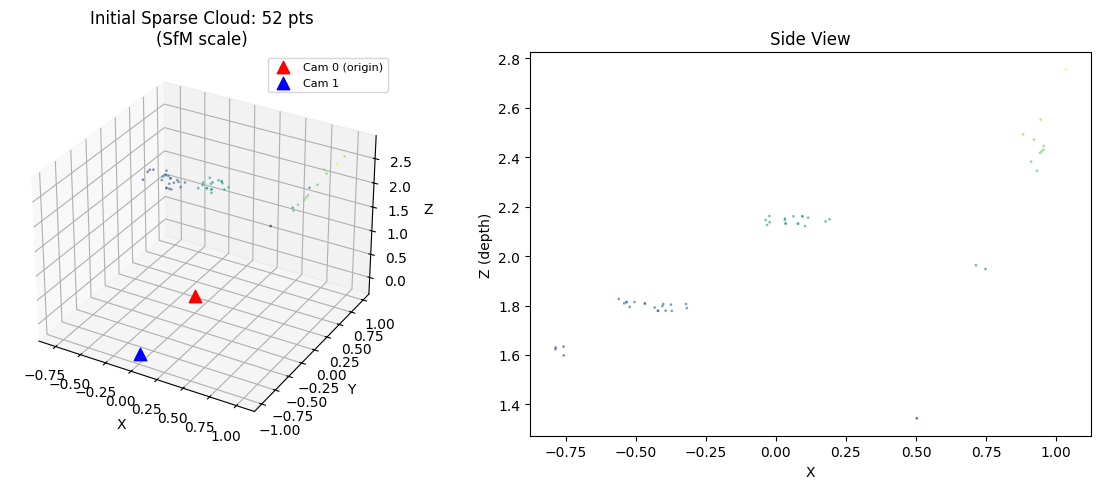

In [7]:
fig = plt.figure(figsize=(12, 5))

ax1 = fig.add_subplot(121, projection='3d')
ax1.scatter(pts3d[:,0], pts3d[:,1], pts3d[:,2],
            s=1, c=pts3d[:,2], cmap='viridis', alpha=0.5)
# Draw the two cameras
ax1.scatter([0], [0], [0], c='red', s=80, marker='^', label='Cam 0 (origin)')
ax1.scatter([t_est[0]], [t_est[1]], [t_est[2]], c='blue', s=80, marker='^', label='Cam 1')
ax1.set_xlabel('X'); ax1.set_ylabel('Y'); ax1.set_zlabel('Z')
ax1.set_title(f'Initial Sparse Cloud: {len(pts3d)} pts\n(SfM scale)')
ax1.legend(fontsize=8)

ax2 = fig.add_subplot(122)
ax2.scatter(pts3d[:,0], pts3d[:,2], s=1, c=pts3d[:,2], cmap='viridis', alpha=0.5)
ax2.set_xlabel('X'); ax2.set_ylabel('Z (depth)')
ax2.set_title('Side View')

plt.tight_layout()
plt.show()

---

## Step 3 — Incremental Camera Registration (PnP)

> **Note:** The two-view decomposition in Steps 1–2 above (`R_est`, `t_est`, `pts3d`) was a
> pedagogical walkthrough — it is **not** passed into `run_incremental_sfm`.
> The function below re-runs the entire process independently, including its own initial-pair
> selection, Essential-matrix decomposition, triangulation, and PnP loop.  This keeps the
> educational demo self-contained without coupling its intermediate state into the production call.

With the initial sparse cloud and two camera poses, we now register the remaining cameras one by one.

### Perspective-n-Point (PnP)

For each unregistered camera, we find feature matches between it and already-registered cameras.  If a matched feature's 3-D point is already in the cloud, we have a **3-D to 2-D correspondence**: we know where the point is in world space ($\mathbf{X}$) and where it appears in the new image ($\mathbf{x}$).

PnP finds the pose $(R, \mathbf{t})$ that minimises reprojection:

$$\min_{R, \mathbf{t}} \sum_i \left\| \pi\bigl(K[R|\mathbf{t}]\mathbf{X}_i\bigr) - \mathbf{x}_i \right\|^2$$

We use `cv2.solvePnPRansac` for robustness to outliers (bad matches that somehow survived earlier filtering).

After registration, new 3-D points are triangulated between the new camera and its registered neighbours, growing the sparse cloud.

In [8]:
from src.sfm.incremental import run_incremental_sfm

print("Running incremental SfM...")
recon = run_incremental_sfm(match_graph, K)

print(f"\nRegistered cameras : {len(recon.cameras)} / {len(images)}")
print(f"3-D points         : {len(recon.points3d)}")
print(f"Observations       : {len(recon.observations)}")
print()
print("Registered camera IDs:", sorted(recon.cameras.keys()))

Running incremental SfM...
[sfm] Init pair (14,15): 52 3D points
[sfm] Registered cam 10: 61 inliers
[sfm] Registered cam 11: 60 inliers
[sfm] Final: 4 cameras, 82 points

Registered cameras : 4 / 16
3-D points         : 82
Observations       : 164

Registered camera IDs: [10, 11, 14, 15]


---

## Step 4 — Bundle Adjustment

### Why BA is Essential

Incremental SfM accumulates errors: each PnP registration inherits the error of all previous steps.  By the time we have registered 16 cameras, the last camera's pose error can be several degrees — much worse than the first camera.

**Bundle Adjustment** (BA) fixes this by optimising all poses and all 3-D points **simultaneously**:

$$\min_{\{R_c, \mathbf{t}_c\},\; \{\mathbf{X}_j\}} \sum_{c,j} \rho\!\left( \left\| \pi(K[R_c|\mathbf{t}_c]\mathbf{X}_j) - \mathbf{x}_{cj} \right\|^2 \right)$$

- The summation runs over all (camera, point) pairs where the point is observed in that camera.
- $\rho(\cdot)$ is the **Huber loss** — it reduces the influence of outlier matches that survived RANSAC.
- The optimisation is a large non-linear least-squares problem, solved by the Levenberg-Marquardt algorithm.

**Degrees of freedom:** each camera has 6 DOF (rotation + translation), each 3-D point has 3 DOF.  For 16 cameras and 1000 points, that's $16 \times 6 + 1000 \times 3 = 3096$ parameters optimised jointly — this is why it's called "bundle" adjustment.

### Huber Loss

$$\rho(r) = \begin{cases} r^2/2 & |r| \le \delta \\ \delta(|r| - \delta/2) & |r| > \delta \end{cases}$$

For small residuals ($|r| \le \delta$), Huber behaves like squared loss.  For large residuals, it is linear — capping the influence of outliers (false matches that skew the optimisation).

In [9]:
from src.sfm.bundle_adjustment import run_bundle_adjustment

print("Running Bundle Adjustment...")
ba_error = run_bundle_adjustment(recon, max_iter=20)
print(f"BA mean reprojection error: {ba_error:.4f} px")
print()
if ba_error < 1.0:
    print("< 1 px — excellent. BA converged well.")
elif ba_error < 2.0:
    print("1–2 px — good. Acceptable for most photogrammetry.")
else:
    print("> 2 px — check for degenerate geometry or bad matches.")

Running Bundle Adjustment...
[BA] mean reprojection error: 0.050 px
BA mean reprojection error: 0.0496 px

< 1 px — excellent. BA converged well.


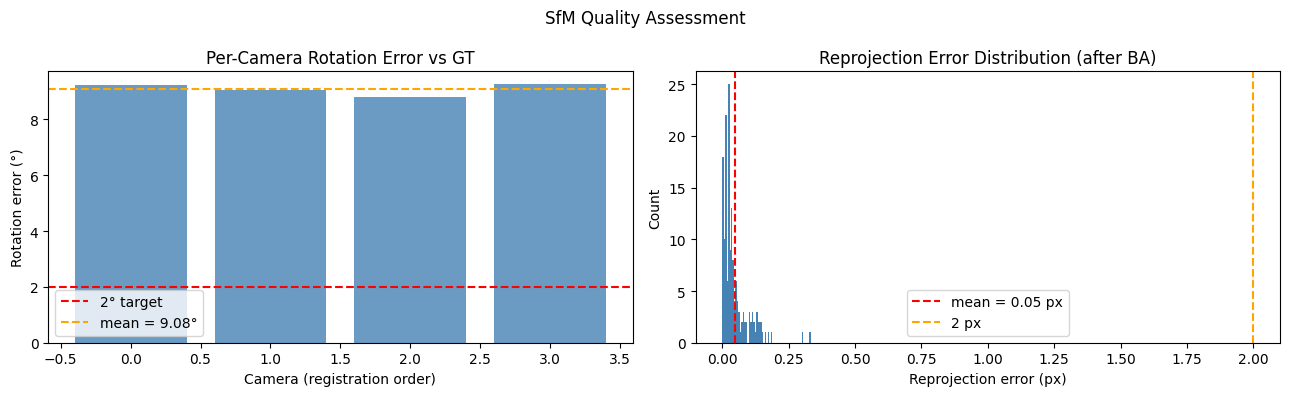

Rotation error:      mean=9.079°,  max=9.258°
Reprojection error:  mean=0.047 px,  median=0.028 px


In [10]:
# Evaluate estimated poses against ground truth.
# Rotation error: angle between R_est and R_gt (via geodesic distance on SO(3)).
angle_errors = []
for cam_id, (R_est_c, t_est_c) in recon.cameras.items():
    R_gt = np.array(gt_poses[cam_id]['R'])
    R_err = R_est_c @ R_gt.T
    cos_a = np.clip((np.trace(R_err) - 1) / 2, -1, 1)
    angle_errors.append(np.degrees(np.arccos(cos_a)))

angle_errors = np.array(angle_errors)
cam_ids = sorted(recon.cameras.keys())

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].bar(range(len(angle_errors)), angle_errors, color='steelblue', alpha=0.8)
axes[0].axhline(2.0, color='red', linestyle='--', label='2° target')
axes[0].axhline(angle_errors.mean(), color='orange', linestyle='--',
                label=f'mean = {angle_errors.mean():.2f}°')
axes[0].set_xlabel('Camera (registration order)')
axes[0].set_ylabel('Rotation error (°)')
axes[0].set_title('Per-Camera Rotation Error vs GT')
axes[0].legend()

# Reprojection errors per observation
errors = []
for (cam_id, pt_id), pt2d in recon.observations.items():
    R_c, t_c = recon.cameras[cam_id]
    X = recon.points3d[pt_id].reshape(1, 3)
    rvec, _ = cv2.Rodrigues(R_c)
    proj, _ = cv2.projectPoints(X, rvec, t_c, K, None)
    errors.append(np.linalg.norm(proj.ravel() - pt2d))

axes[1].hist(errors, bins=60, color='steelblue', edgecolor='none')
axes[1].axvline(np.mean(errors), color='red', linestyle='--',
                label=f'mean = {np.mean(errors):.2f} px')
axes[1].axvline(2.0, color='orange', linestyle='--', label='2 px')
axes[1].set_xlabel('Reprojection error (px)')
axes[1].set_ylabel('Count')
axes[1].set_title('Reprojection Error Distribution (after BA)')
axes[1].legend()

plt.suptitle('SfM Quality Assessment', fontsize=12)
plt.tight_layout()
plt.show()

print(f"Rotation error:      mean={angle_errors.mean():.3f}°,  max={angle_errors.max():.3f}°")
print(f"Reprojection error:  mean={np.mean(errors):.3f} px,  median={np.median(errors):.3f} px")

In [11]:
pts = recon.get_3d_points_array()
pcd = o3d.geometry.PointCloud()
pcd.points = o3d.utility.Vector3dVector(pts)

out_dir = os.path.join('..', 'outputs')
os.makedirs(out_dir, exist_ok=True)

# Save sparse point cloud
out_path = os.path.join(out_dir, 'sparse_cloud.ply')
o3d.io.write_point_cloud(out_path, pcd)
print(f"Sparse cloud saved: {out_path}  ({len(pts)} points)")

# Save estimated camera poses → used by Phase 8 for full-pipeline pose error evaluation.
# Each entry stores cam_id, R, t (SfM scale), and K.
est_poses_list = [
    {'cam_id': cam_id, 'R': R_c.tolist(), 't': t_c.tolist(), 'K': K.tolist()}
    for cam_id, (R_c, t_c) in sorted(recon.cameras.items())
]
est_poses_path = os.path.join(out_dir, 'estimated_poses.json')
with open(est_poses_path, 'w') as f:
    json.dump(est_poses_list, f, indent=2)

print(f"Estimated poses saved: {est_poses_path}  ({len(est_poses_list)} cameras)")
print()
print("Scale note: SfM poses are in arbitrary scale (|t_init| = 1 by convention).")
print("Phase 4 uses GT poses for metric depth — see the explanation cell in Phase 4.")
print("Phase 8 uses these estimated poses to measure rotation error in degrees.")

Sparse cloud saved: ..\outputs\sparse_cloud.ply  (82 points)
Estimated poses saved: ..\outputs\estimated_poses.json  (4 cameras)

Scale note: SfM poses are in arbitrary scale (|t_init| = 1 by convention).
Phase 4 uses GT poses for metric depth — see the explanation cell in Phase 4.
Phase 8 uses these estimated poses to measure rotation error in degrees.


### Key Insight: Error Accumulation and BA

Notice in the rotation-error bar chart that **later-registered cameras often have larger errors**.  This is the error drift of incremental SfM: each new camera's pose is estimated relative to the already-estimated (imperfect) world.

Bundle Adjustment is the only way to fix this — by treating all poses as free variables and jointly minimising all reprojection errors, it distributes the error evenly rather than letting it accumulate on the last cameras.

A practical rule: **run BA after every 5–10 new camera registrations**, not just at the end.  Many production systems (Colmap, OpenMVG) do this.

---

## Summary

| Step | Algorithm | Output |
|---|---|---|
| Initial pair selection | Most inliers + sufficient baseline | Image pair (i, j) |
| Essential matrix | 5-point / 8-point + RANSAC | $E$ |
| Relative pose | `cv2.recoverPose` + cheirality | $R$, $\mathbf{t}$ (unit scale) |
| Triangulation | DLT (SVD) | Sparse 3-D cloud |
| Registration | PnP (Ransac) | New camera poses |
| Refinement | Bundle Adjustment (Huber) | Accurate poses + cloud |

### Questions to Think About

- Why does SfM only recover unit-scale translation?  What information would you need to recover metric scale?
- If one camera fails to register (no PnP inliers), what happens to its downstream depth estimation in Phase 4?  What should you do?
- The initial pair should have both many inliers AND a large baseline.  Why is a very short baseline bad even with many inliers?  (Hint: consider the triangulation angle.)
- Huber loss caps the influence of residuals larger than $\delta$.  What is a good value for $\delta$ in pixels?  Too small?  Too large?

---

**Next → [Phase 4: Dense Depth Estimation (MVS)](phase4_mvs.ipynb)**